## Static Test Results

In [1]:
import os, re
import json
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FormatStrFormatter

from datetime import datetime
import math
import pandas as pd
from itertools import chain

from utils import post_process_get_moving_test_data_and_timestamp
from utils import remove_outlier_by_quantile
from static_data_processing import get_test_files_and_survey
from plot_utils import *
from stats_utils import *

from pandas.core.common import SettingWithCopyWarning
import warnings
warnings.simplefilter(action='ignore', category=SettingWithCopyWarning)

from collections import defaultdict

ROOT_DIR = os.path.join("C:/Users/wangz/OneDrive/University_RU/NSUWB/")
CALIBRATED_CAM_TO_V2B = -6400.8
pd.set_option('display.float_format', lambda x: '%.5f' % x)
pd.set_option('display.max_columns', None)

RESAMPLE_RULE = "1S"
PLOTTING_DPI = 75
static_main_master = '0C1A'
static_focusing_slaves = ['1912', '8D38']
static_master_slave_mapping = { '0C1A': [static_focusing_slaves[0], static_focusing_slaves[1]],
                        '9B0F': [static_focusing_slaves[1], static_focusing_slaves[0]]}
moving_main_master = '88BA'
moving_focusing_slaves = ['45BA', '0B8A']
moving_master_slave_mapping = { '88BA': [moving_focusing_slaves[0], moving_focusing_slaves[1]],
                        '111C': [moving_focusing_slaves[1], moving_focusing_slaves[0]]}
STATIC_VEH, MOVING_VEH = 1, 2
VEH_NAME_MAP = {1: "static", 2: "moving"}
test_preset_map = defaultdict(dict)
test_preset_map[STATIC_VEH]['master_slave_mapping'] = static_master_slave_mapping
test_preset_map[MOVING_VEH]['master_slave_mapping'] = moving_master_slave_mapping
test_preset_map[STATIC_VEH]['main_master'] = static_main_master
test_preset_map[MOVING_VEH]['main_master'] = moving_main_master
#############################################
# if skip plotting any tests, list them here
skiptests = []
#############################################
all_test_files = get_test_files_and_survey("Static Test", "V2")[0]
all_test_names_dup = [os.path.basename(os.path.dirname(f)) for f in all_test_files]
# Remove Duplicates of Test Names
all_test_names = []
_ = [all_test_names.append(x) for x in all_test_names_dup if x not in all_test_names]
test_raw_name_file_map = {}
for i in range(len(all_test_names)):
    test_raw_name_file_map[all_test_names[i]] = {}
    a_side_file, b_side_file = all_test_files[2*i], all_test_files[2*i+1]
    test_raw_name_file_map[all_test_names[i]]["A"] = a_side_file
    test_raw_name_file_map[all_test_names[i]]["B"] = b_side_file
    test_raw_name_file_map[all_test_names[i]]["ground_truth"] = None
static_tests = {}

In [2]:
def plot_single_test_data(raw_name):
    parsing_results = static_tests.get(raw_name)
    if not parsing_results:
        print(raw_name + " No Data, Not Plotting")
        return

    # Unpack dataframes
    df_outlier_overall = parsing_results["df_outlier_overall"]
    moving_ground_truth_df = parsing_results["moving_ground_truth_df"]
    for veh in parsing_results["vehicles"]:
        df_veh_time_idx = parsing_results[veh]["df_veh_time_idx"]
        df_veh_dist_idx = parsing_results[veh]["df_veh_dist_idx"]
        veh_err_bins = parsing_results[veh]["veh_err_bins"]
        df_stats_pairwise = parsing_results[veh]['df_stats_pairwise']
        df_stats_aggregated = parsing_results[veh]['df_stats_aggregated']
        if veh == STATIC_VEH:
            df_static_time_idx, static_bins = df_veh_time_idx, veh_err_bins
        elif veh == MOVING_VEH:
            df_moving_time_idx, moving_bins = df_veh_time_idx, veh_err_bins

    ######################################################
    ########## Original Results ##########
    ######################################################
    print("plotting: " + raw_name)
    figure = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
    if "moving" in raw_name.split("-v2-")[0]:
        titlename = "Moving Test - " + raw_name.split("-v2-")[-1]
        figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
    elif "virtual" in raw_name.split("-v2-")[0]:
        titlename = "Virtual Moving Test - " + raw_name.split("-v2-")[-1]
        figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
    elif "static" in raw_name.split("-v2-")[0]:
        static_surveyed_dist = df_static_time_idx["Surveyed Distance (mm)"].get(0, float('nan'))
        titlename = "Static Test - " + raw_name.split("-v2-")[-1]  + " - " + str(int(static_surveyed_dist)) + "mm"
        figure.suptitle(titlename, fontsize='x-large', fontweight='bold')
        figure2 = plt.figure(figsize=(16, 9), dpi=PLOTTING_DPI)
        
                
    print("plotting: " + raw_name + " with Ground Truth Distance: " + str(round(static_surveyed_dist)) + "mm")
    ######################################################
    # Plotting individual tests
    ######################################################
    
    plot_time_series_dist(figure=figure,
                          arrange_spec=221,
                          static_veh_df=df_static_time_idx,
                          moving_veh_df=df_moving_time_idx,
                          static_veh=STATIC_VEH,
                          moving_veh=MOVING_VEH,
                          df_outlier=df_outlier_overall,
                          surveyed_static_ground_truth_value=static_surveyed_dist,
                          moving_ground_truth_df=None,
                          fill=False,
                          resample=False, 
                          scatter=False)
    
    plot_upd_rate(figure=figure,
                  arrange_spec=223,
                  static_veh_df=df_static_time_idx, 
                  moving_veh_df=df_moving_time_idx, 
                  static_veh=STATIC_VEH, 
                  moving_veh=MOVING_VEH, 
                  moving_ground_truth_df=None,
                  resample=True, 
                  scatter=False)
    
    plot_hist(  figure=figure,  
                arrange_spec=222, 
                veh_df=df_static_time_idx,
                bin_size=static_bins, 
                ground_truth_value=static_surveyed_dist,
                master_slave_mapping=static_master_slave_mapping,
                disp_range=static_hist_disp_range,
                hist_title="Hist - Vehicle {} (Static) against Vehicle {} (Mover)".format(STATIC_VEH, MOVING_VEH))
    plot_hist(  figure=figure,  
                arrange_spec=224, 
                veh_df=df_moving_time_idx,
                bin_size=moving_bins, 
                ground_truth_value=static_surveyed_dist,
                master_slave_mapping=moving_master_slave_mapping,
                disp_range=moving_hist_disp_range, 
                hist_title="Hist - Vehicle {} (Mover) against Vehicle {} (Static)".format(MOVING_VEH, STATIC_VEH))
    
    plot_hist_hbar(figure=figure2,  
                   veh1_df=df_static_time_idx,
                   veh2_df=df_moving_time_idx,
                   veh1_bin_size=static_bins,
                   veh2_bin_size=moving_bins, 
                   ground_truth_value=static_surveyed_dist,
                   static_master_slave_mapping=static_master_slave_mapping,
                   moving_master_slave_mapping=moving_master_slave_mapping,                       
                   static_disp_range=static_hist_disp_range, 
                   moving_disp_range=moving_hist_disp_range, 
                   hist_title="Hist - Vehicle {} (Mover) against Vehicle {} (Static)".format(MOVING_VEH, STATIC_VEH))
    plt.show()

## 2021-05-25-08-47-11-static-v2-2

processing: 2021-05-25-08-47-11-static-v2-2
plotting: 2021-05-25-08-47-11-static-v2-2
plotting: 2021-05-25-08-47-11-static-v2-2 with Ground Truth Distance: 6002mm


NameError: name 'static_hist_disp_range' is not defined

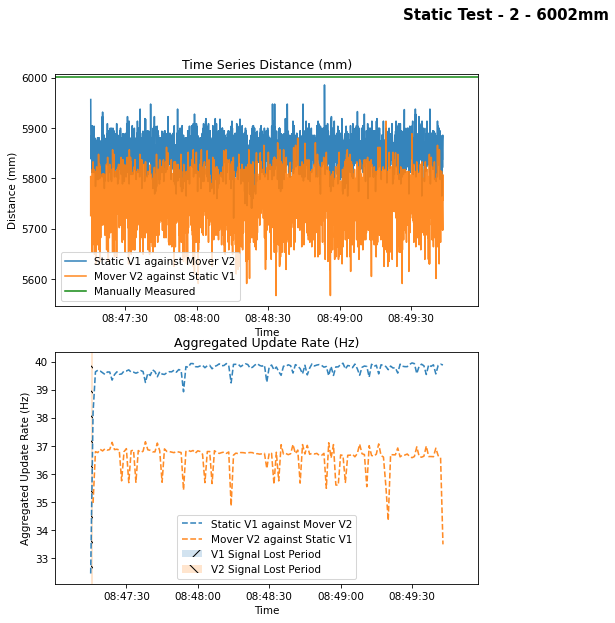

<Figure size 1200x675 with 0 Axes>

In [3]:
test_2 = all_test_names[0]
static_tests[test_2] = parse_single_test_data(test_raw_name_file_map[test_2]["B"], "Static Test")
plot_single_test_data(test_2)

## 2021-05-25-08-52-15-static-v2-3

processing: 2021-05-25-08-52-15-static-v2-3
plotting: 2021-05-25-08-52-15-static-v2-3
plotting: 2021-05-25-08-52-15-static-v2-3 with Ground Truth Distance: 7800mm


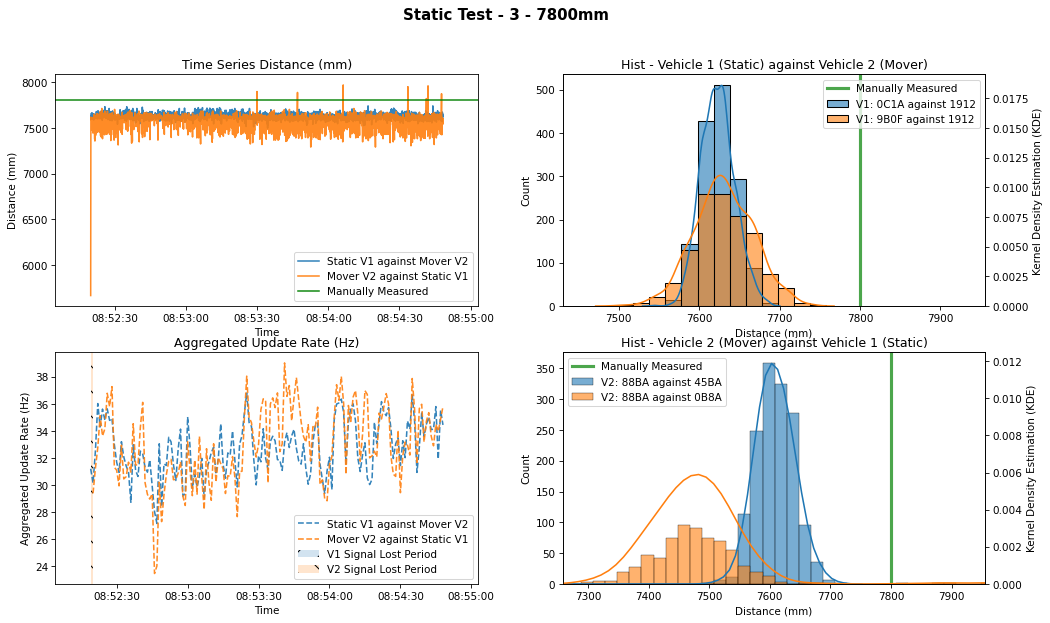

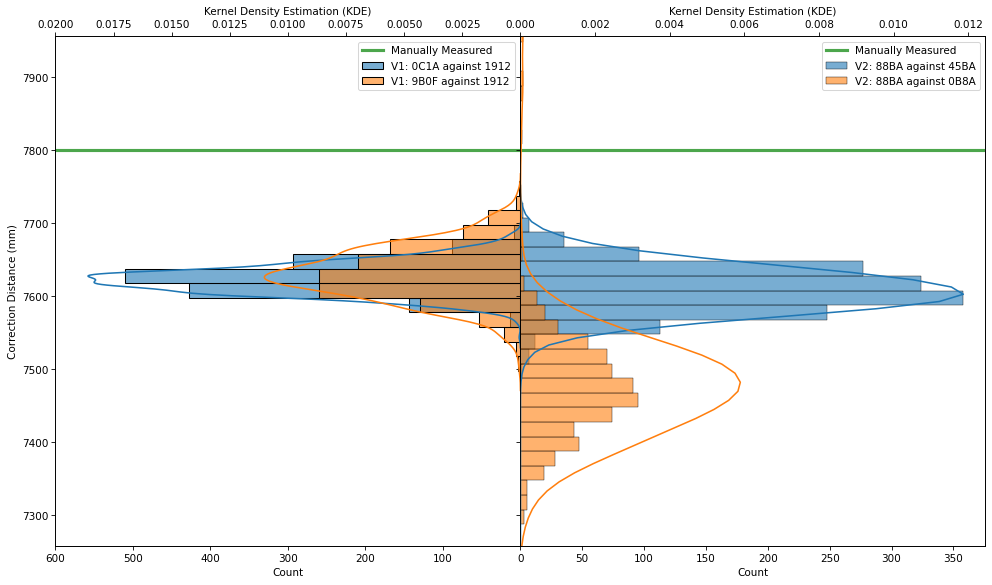

In [ ]:
test_3 = all_test_names[1]
static_tests[test_3] = parse_single_test_data(test_raw_name_file_map[test_3]["B"], "Static Test")
plot_single_test_data(test_3)

## 2021-05-25-08-52-15-static-v2-4

processing: 2021-05-25-08-55-36-static-v2-4
plotting: 2021-05-25-08-55-36-static-v2-4
plotting: 2021-05-25-08-55-36-static-v2-4 with Ground Truth Distance: 9541mm


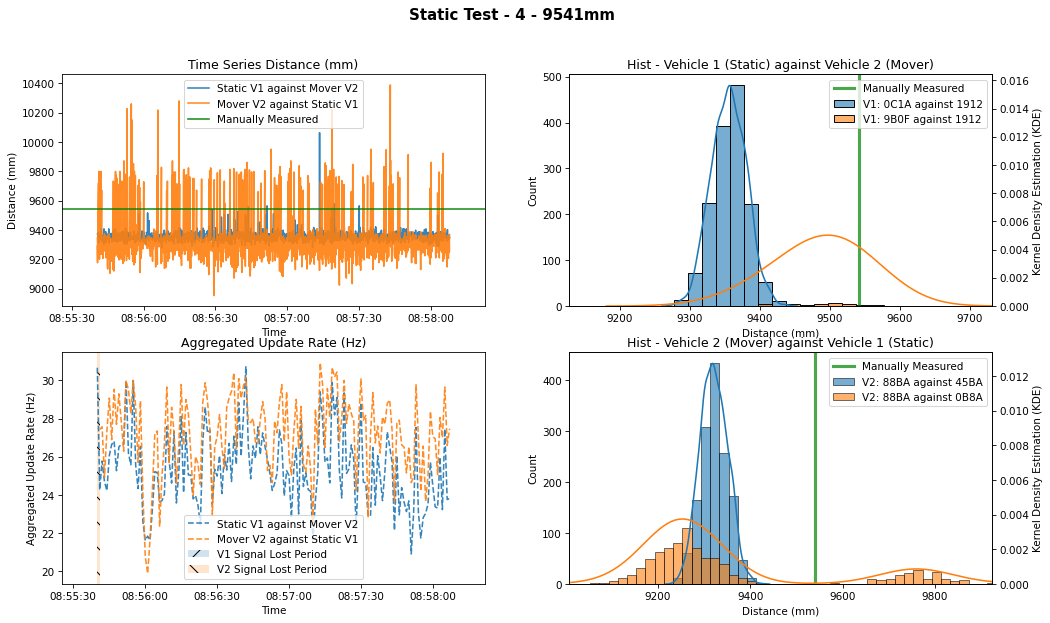

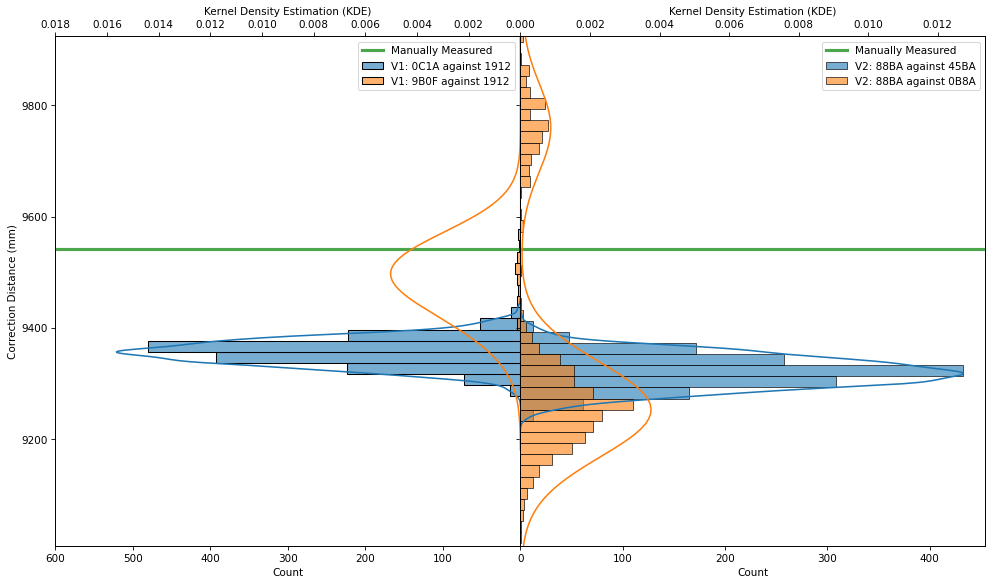

In [ ]:
test_4 = all_test_names[2]
static_tests[test_4] = parse_single_test_data(test_raw_name_file_map[test_4]["B"], "Static Test")
plot_single_test_data(test_4)

## 2021-05-25-08-52-15-static-v2-5

processing: 2021-05-25-09-08-13-static-v2-5
plotting: 2021-05-25-09-08-13-static-v2-5
plotting: 2021-05-25-09-08-13-static-v2-5 with Ground Truth Distance: 11278mm


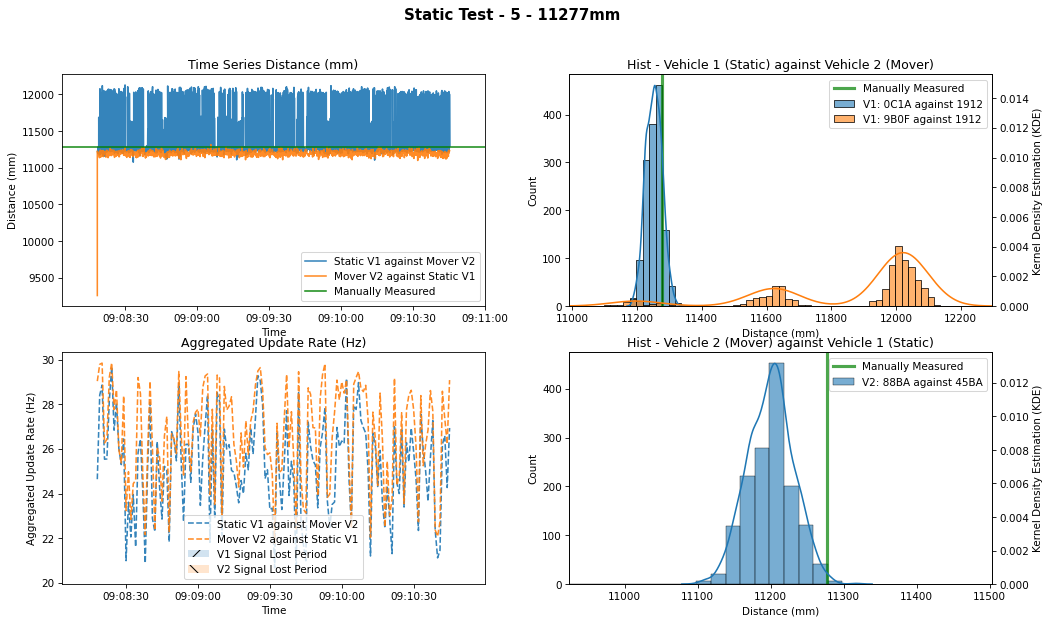

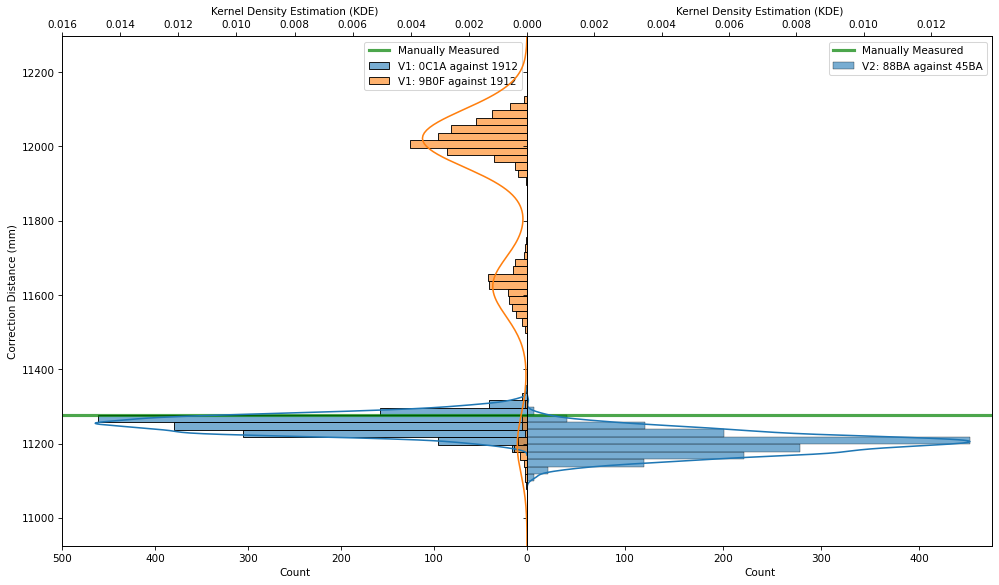

In [ ]:
test_5 = all_test_names[3]
static_tests[test_5] = parse_single_test_data(test_raw_name_file_map[test_5]["B"], "Static Test")
plot_single_test_data(test_5)

## 2021-05-25-08-52-15-static-v2-6

processing: 2021-05-25-09-12-21-static-v2-6
plotting: 2021-05-25-09-12-21-static-v2-6
plotting: 2021-05-25-09-12-21-static-v2-6 with Ground Truth Distance: 13094mm


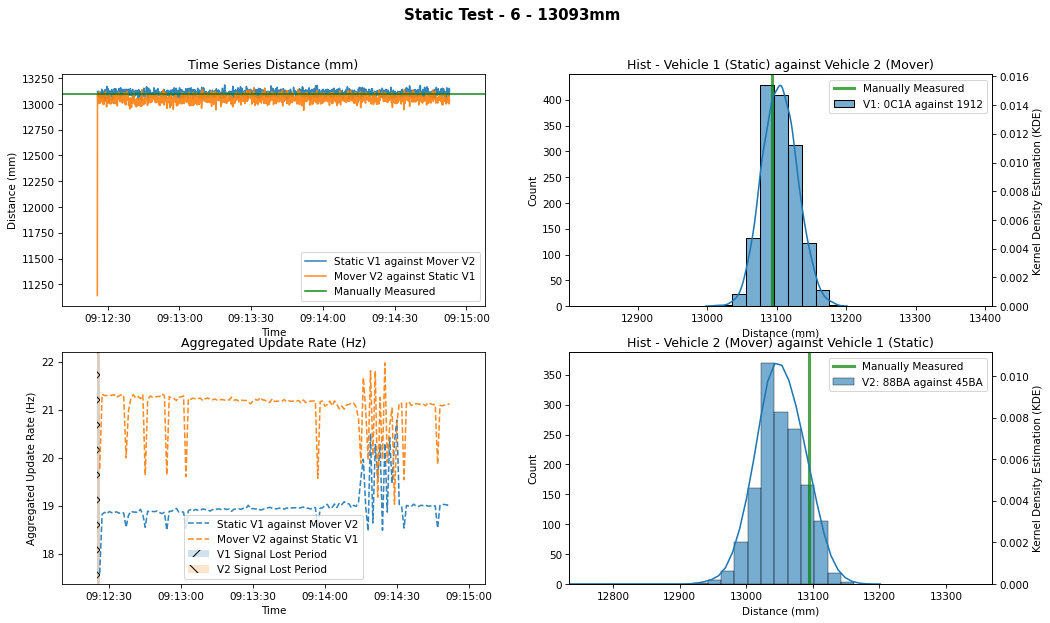

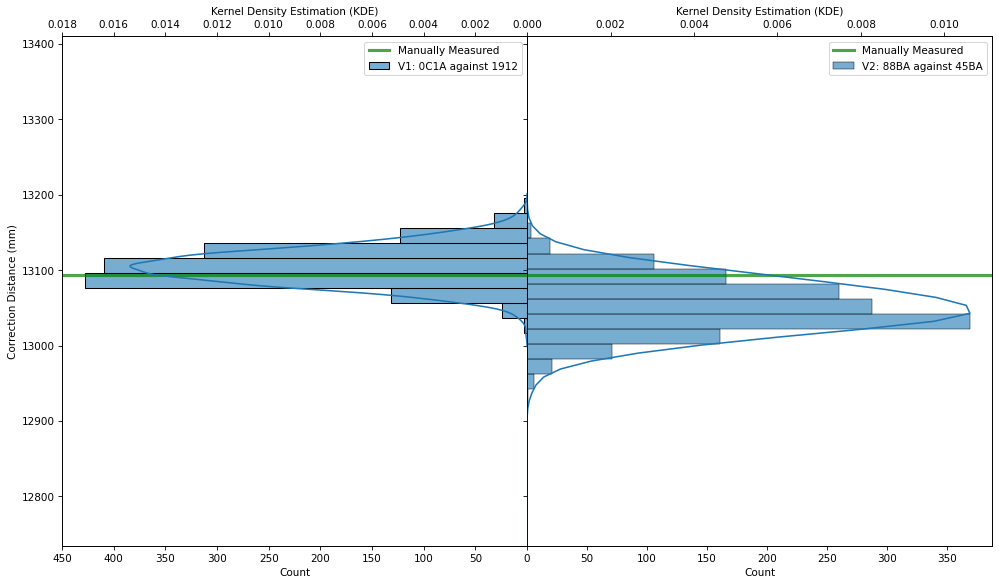

In [ ]:
test_6 = all_test_names[4]
static_tests[test_6] = parse_single_test_data(test_raw_name_file_map[test_6]["B"], "Static Test")
plot_single_test_data(test_6)

## 2021-05-25-08-52-15-static-v2-7

processing: 2021-05-25-09-16-22-static-v2-7
plotting: 2021-05-25-09-16-22-static-v2-7
plotting: 2021-05-25-09-16-22-static-v2-7 with Ground Truth Distance: 14973mm


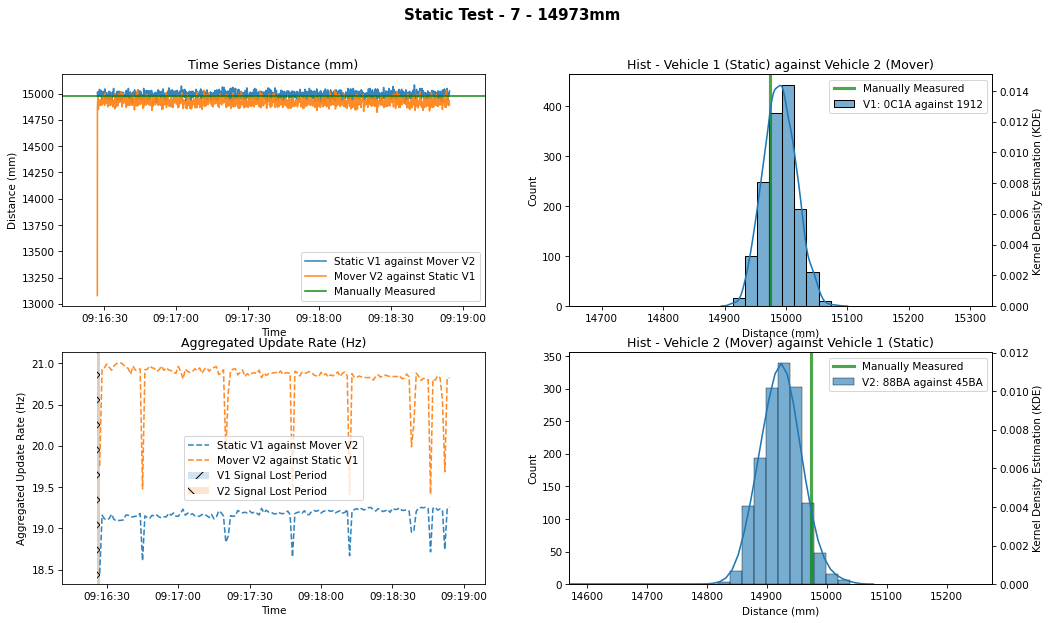

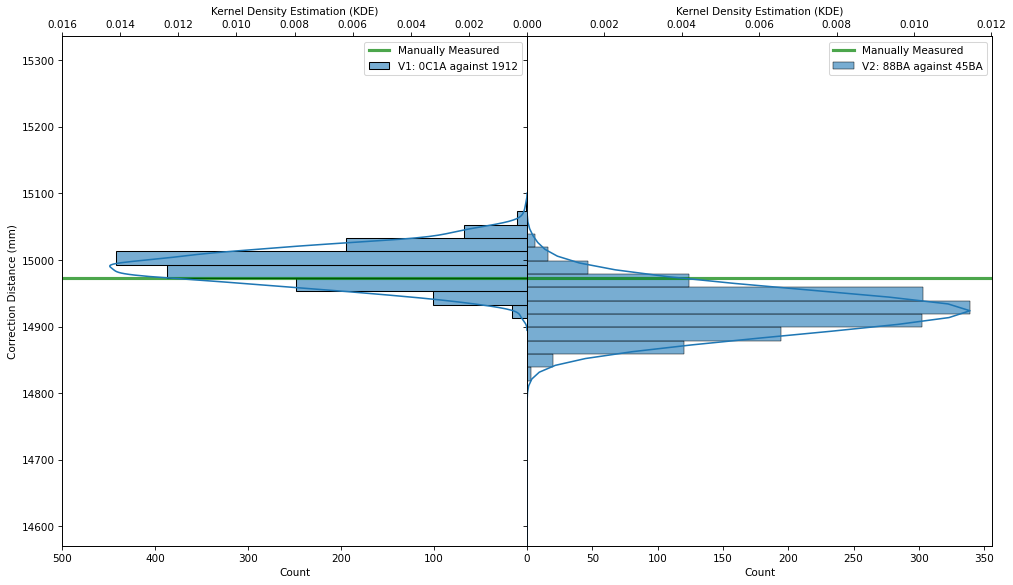

In [ ]:
test_7 = all_test_names[5]
static_tests[test_7] = parse_single_test_data(test_raw_name_file_map[test_7]["B"], "Static Test")
plot_single_test_data(test_7)

## 2021-05-25-08-52-15-static-v2-8

processing: 2021-05-25-09-20-18-static-v2-8
plotting: 2021-05-25-09-20-18-static-v2-8
plotting: 2021-05-25-09-20-18-static-v2-8 with Ground Truth Distance: 17247mm


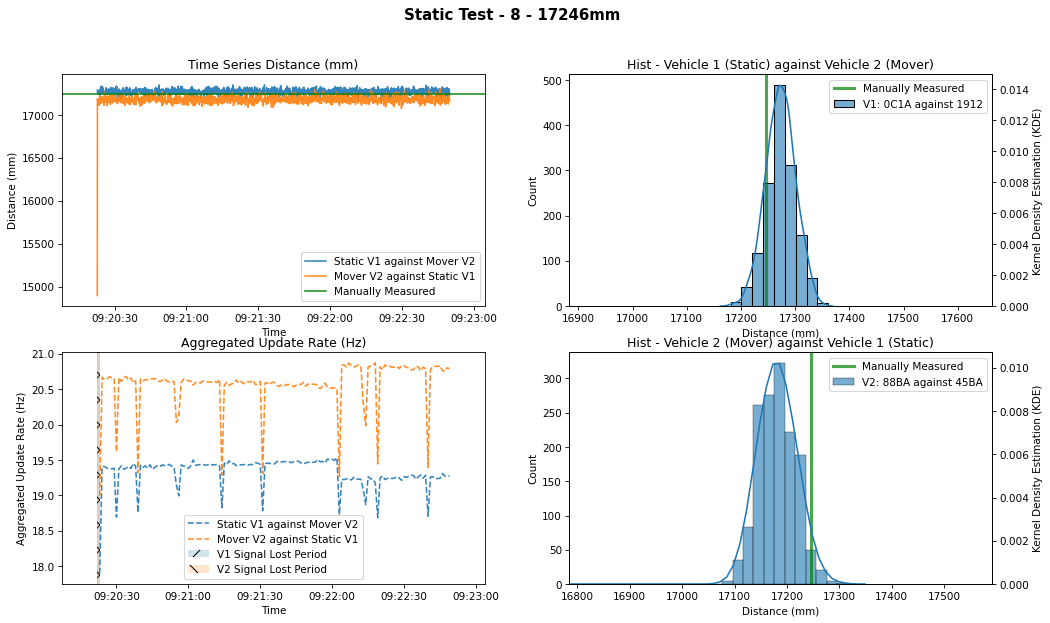

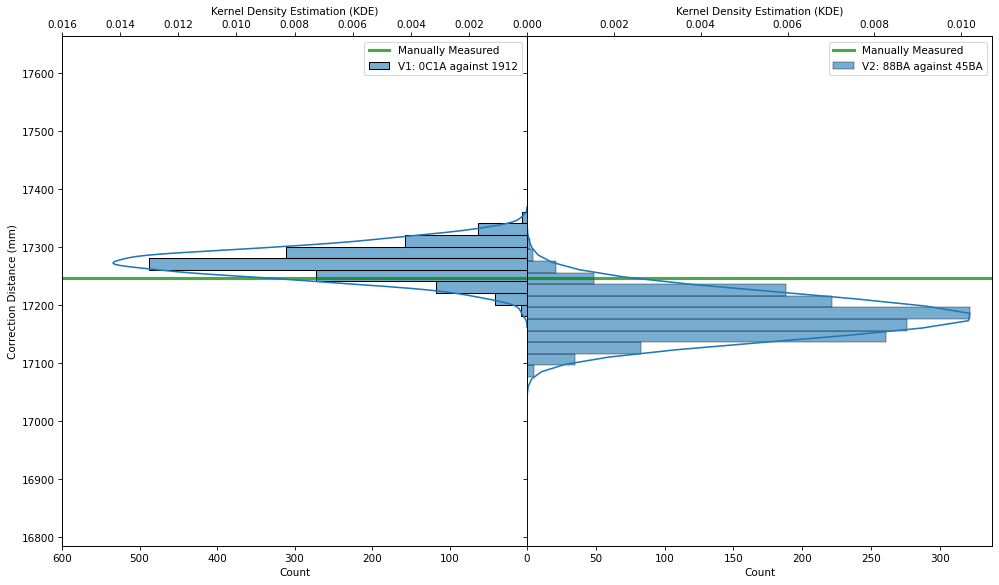

In [ ]:
test_8 = all_test_names[6]
static_tests[test_8] = parse_single_test_data(test_raw_name_file_map[test_8]["B"], "Static Test")
plot_single_test_data(test_8)

## 2021-05-25-08-52-15-static-v2-9

processing: 2021-05-25-09-23-50-static-v2-9
plotting: 2021-05-25-09-23-50-static-v2-9
plotting: 2021-05-25-09-23-50-static-v2-9 with Ground Truth Distance: 18986mm


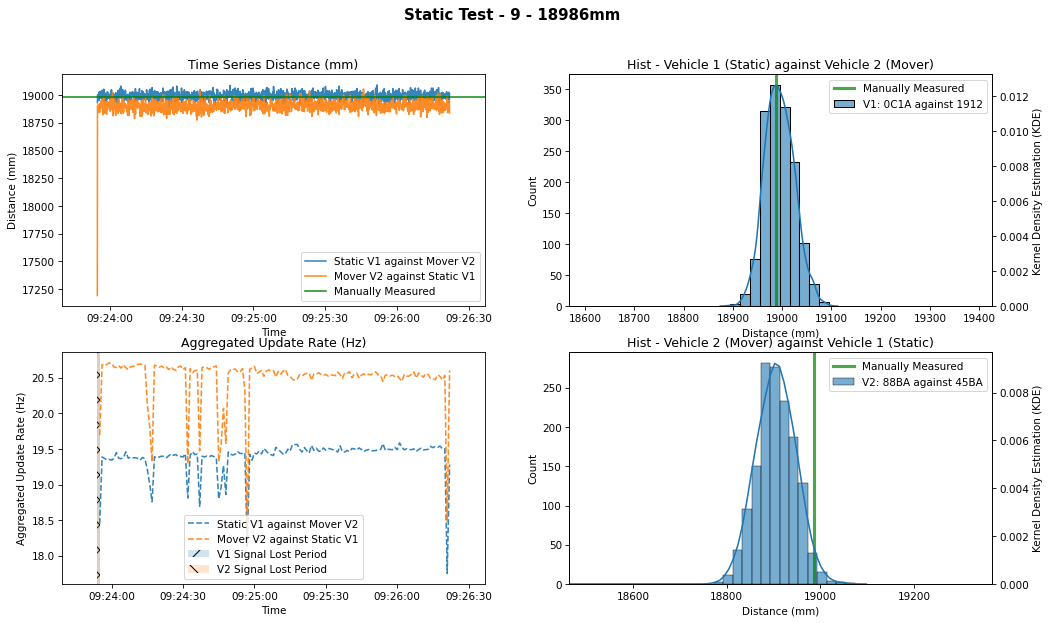

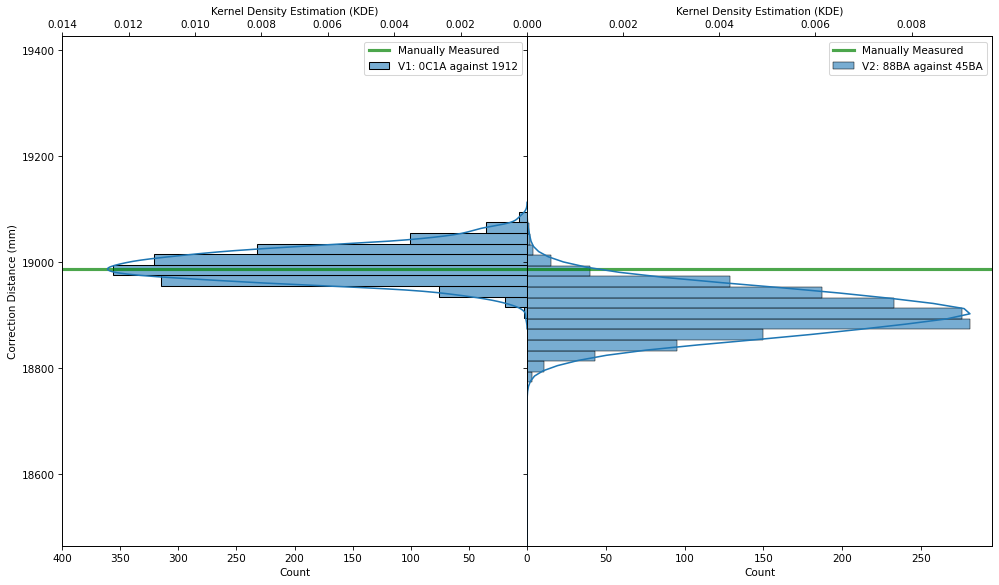

In [ ]:
test_9 = all_test_names[7]
static_tests[test_9] = parse_single_test_data(test_raw_name_file_map[test_9]["B"], "Static Test")
plot_single_test_data(test_9)

## 2021-05-25-08-52-15-static-v2-10

processing: 2021-05-25-09-27-41-static-v2-10
plotting: 2021-05-25-09-27-41-static-v2-10
plotting: 2021-05-25-09-27-41-static-v2-10 with Ground Truth Distance: 21736mm


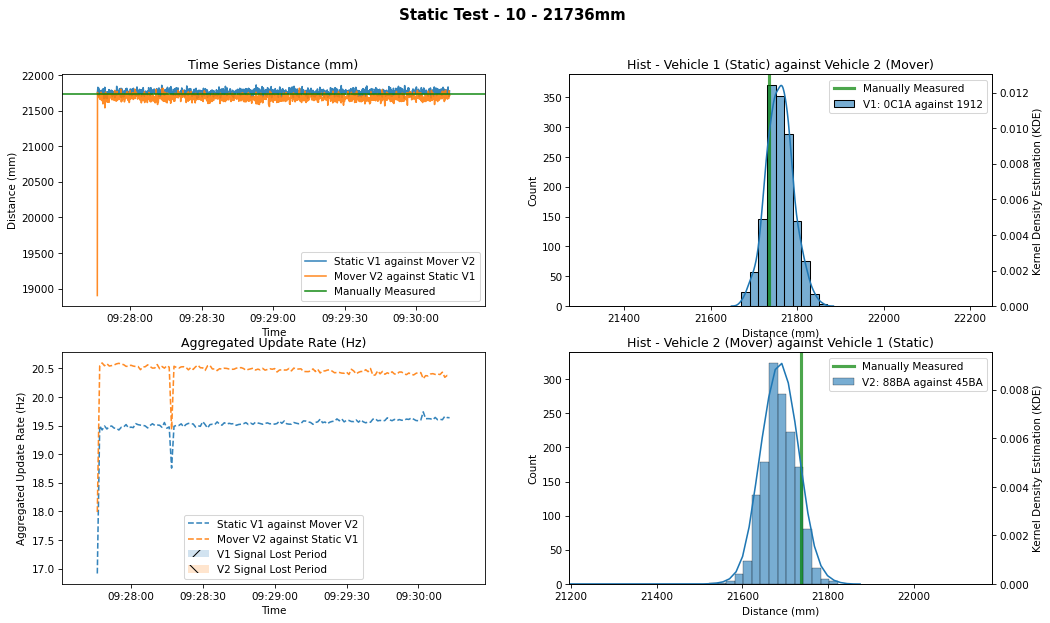

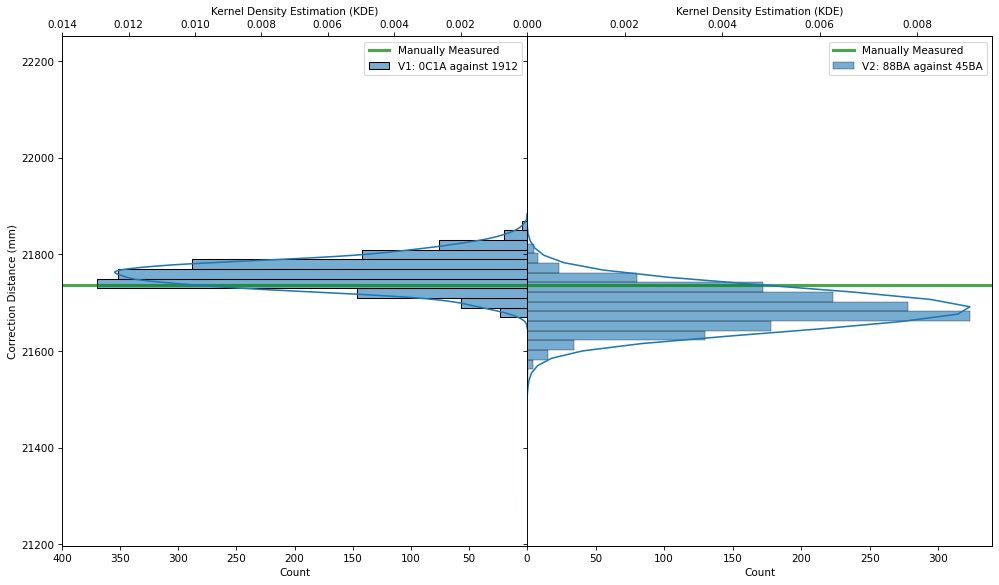

In [ ]:
test_10 = all_test_names[8]
static_tests[test_10] = parse_single_test_data(test_raw_name_file_map[test_10]["B"], "Static Test")
plot_single_test_data(test_10)

## 2021-05-25-08-52-15-static-v2-11

processing: 2021-05-25-09-31-46-static-v2-11
plotting: 2021-05-25-09-31-46-static-v2-11
plotting: 2021-05-25-09-31-46-static-v2-11 with Ground Truth Distance: 24651mm


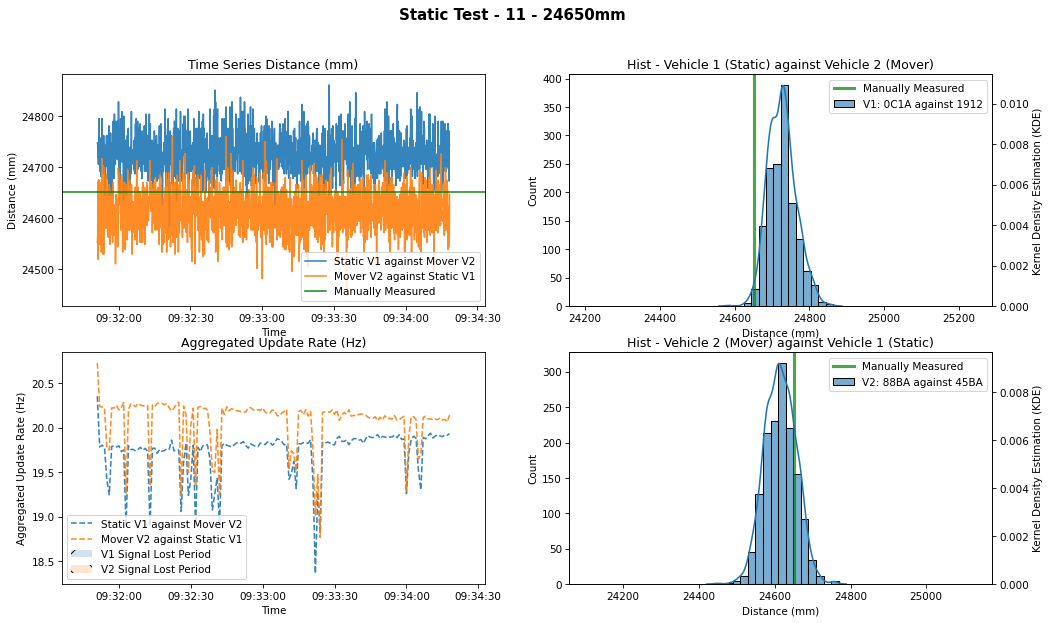

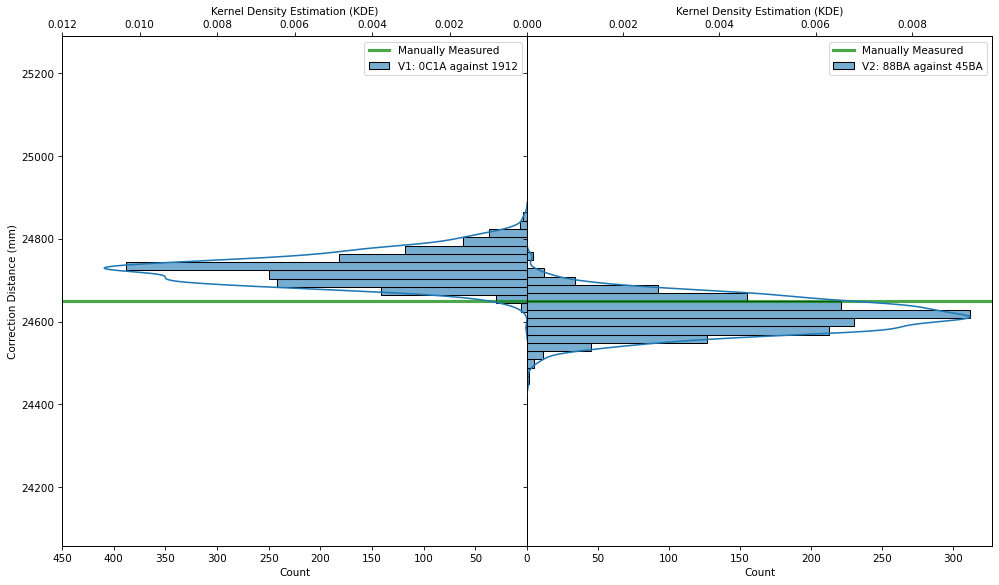

In [ ]:
test_11 = all_test_names[9]
static_tests[test_11] = parse_single_test_data(test_raw_name_file_map[test_11]["B"], "Static Test")
plot_single_test_data(test_11)

## 2021-05-25-08-52-15-static-v2-12

processing: 2021-05-25-09-35-42-static-v2-12
plotting: 2021-05-25-09-35-42-static-v2-12
plotting: 2021-05-25-09-35-42-static-v2-12 with Ground Truth Distance: 27381mm


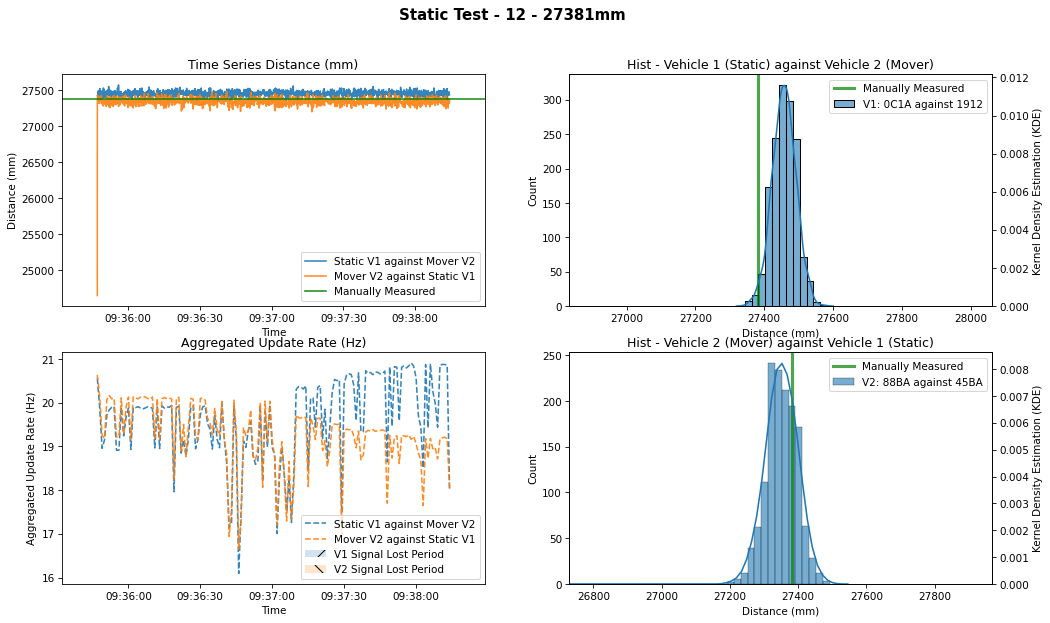

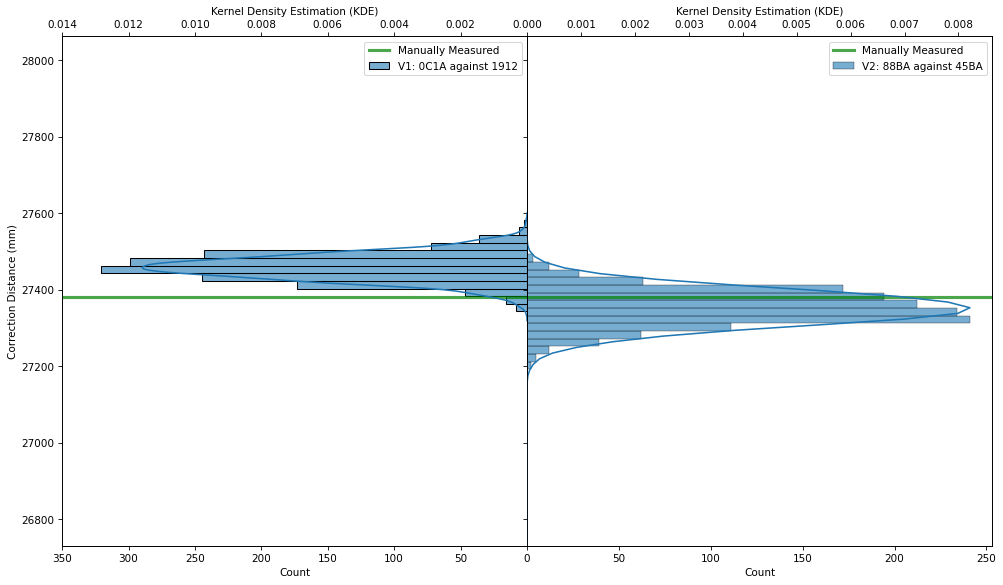

In [ ]:
test_12 = all_test_names[10]
static_tests[test_12] = parse_single_test_data(test_raw_name_file_map[test_12]["B"], "Static Test")
plot_single_test_data(test_12)

## 2021-05-25-08-52-15-static-v2-13

processing: 2021-05-25-09-39-16-static-v2-13
plotting: 2021-05-25-09-39-16-static-v2-13
plotting: 2021-05-25-09-39-16-static-v2-13 with Ground Truth Distance: 29877mm


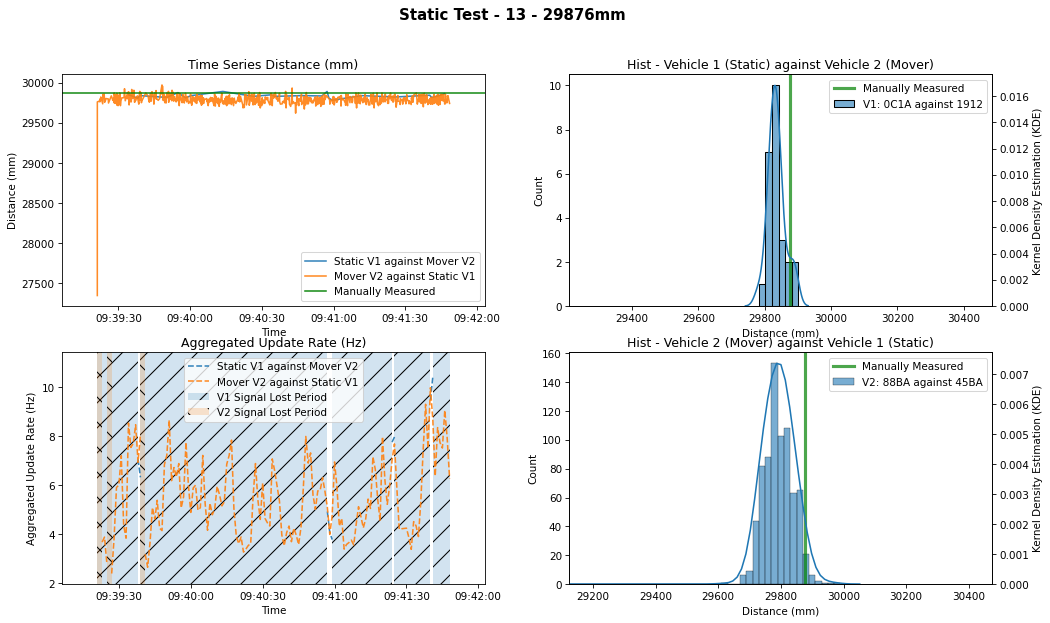

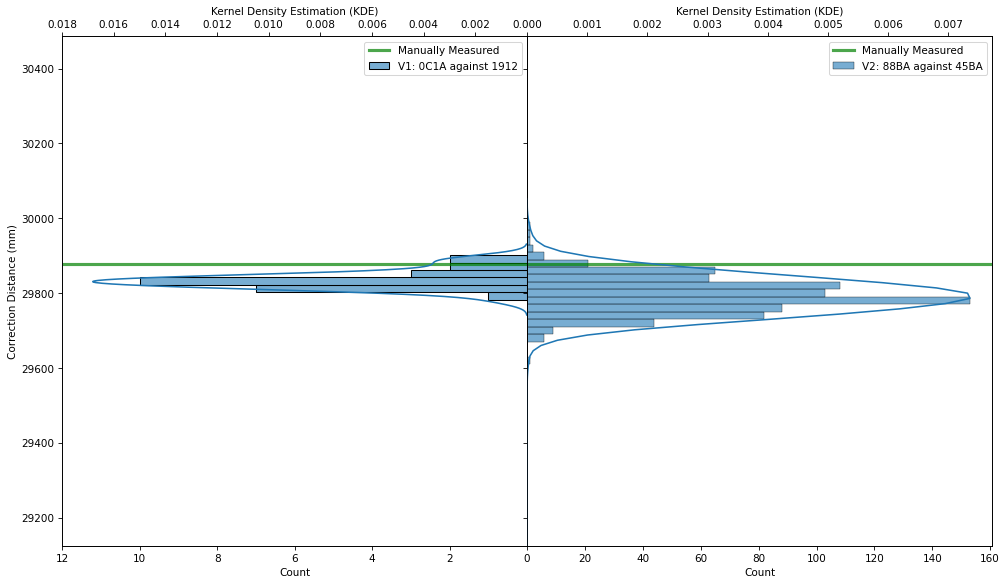

In [ ]:
test_13 = all_test_names[11]
static_tests[test_13] = parse_single_test_data(test_raw_name_file_map[test_13]["B"], "Static Test")
plot_single_test_data(test_13)

## 2021-05-25-08-52-15-static-v2-14

processing: 2021-05-25-09-42-52-static-v2-14
plotting: 2021-05-25-09-42-52-static-v2-14
plotting: 2021-05-25-09-42-52-static-v2-14 with Ground Truth Distance: 32499mm


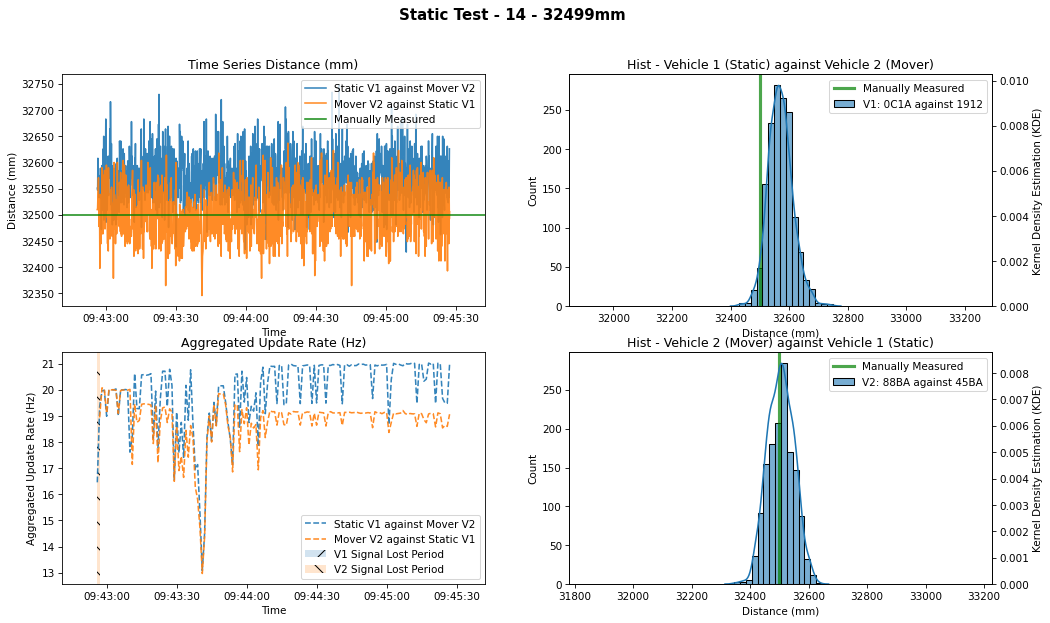

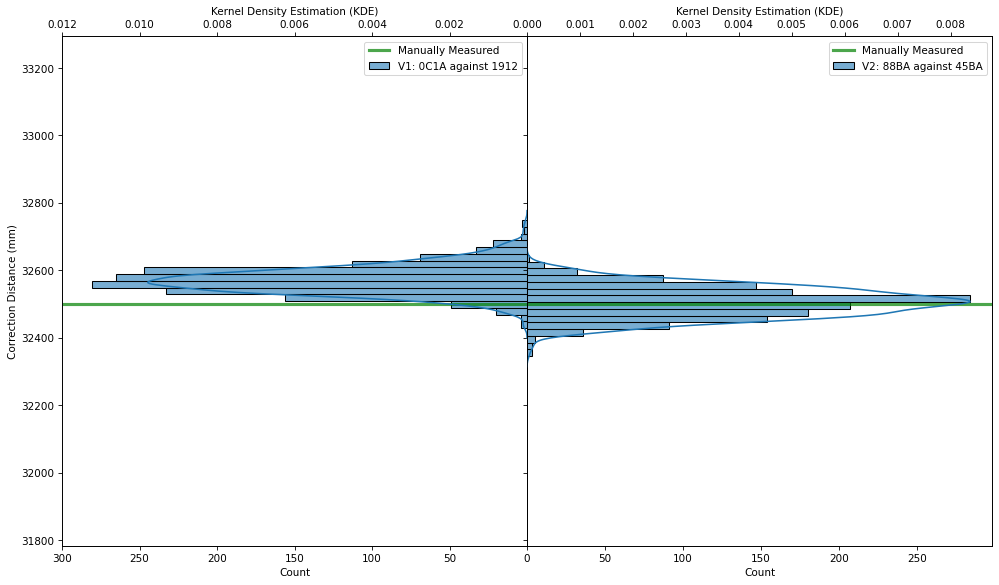

In [ ]:
test_14 = all_test_names[12]
static_tests[test_14] = parse_single_test_data(test_raw_name_file_map[test_14]["B"], "Static Test")
plot_single_test_data(test_14)